# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

## Representação de Documentos usando o Esquema de Pesos TF-IDF

Objetivos: <br>
- Apresentar o modelo de represenção de documentos usando o esquema de pesos TF-IDF. Ele é usado para converter os textos de entrada em uma representação numérica por meio dos chamados "embeddings" (ou vetores numéricos n-dimensionais).
- Apresentar como usar esses embeddings para as tarefas de busca léxica e classificação de textos.

Você vai aprender a:
- Gerar embeddings de textos usando o esquema de pesos TF-IDF.
- Usar a similaridade do Cosseno para medir a similaridade entre textos.
- Classificar textos de notícias em categorias específicas.

Referências: <br>
https://goodboychan.github.io/python/datacamp/natural_language_processing/2020/07/17/04-TF-IDF-and-similarity-scores.html <br>
https://medium.com/web-mining-is688-spring-2021/cosine-similarity-and-tfidf-c2a7079e13fa <br>
https://medium.com/@claude.feldges/text-classification-with-tf-idf-lstm-bert-a-quantitative-comparison-b8409b556cb3 <br>

Versão: Maio, 2023

## Geração de *Embeddings* com o Esquema de Pesos TF-IDF

TF (Term Frequency) e IDF (Inverse Document Frequency) são a base de um esquema de pesos denominado TF-IDF, que modela um documento pela frequência de seus termos e pela raridade deles na coleção de documentos.

Um termo pode ser uma palavra ou uma sequência de $n$ palavras ($n$-gram) ou uma sequência de caracteres de tamanho $n$ ($n$-gram de caracteres).

**Representação de Documentos**

Um documento $j$ é representado pelo vetor $\overrightarrow{d_j}$ dado por:<br>
$\overrightarrow{d_j} = (w_{1j},w_{2j},\dots,w_{tj})$<br>

onde:<br>
$w_{ij}$ é o peso do termo $i$ no documento $j$<br>
$t$ é o número de termos distintos na coleção de documentos<br>

Logo, o vetor $\overrightarrow{d_j}$ tem $t$ dimensões, formando um *embedding* $t$-dimensional.

**TF**

O valor de $w_{ij}$ é proporcional à frequência do termo ($f_{i,j}$). A frequência é simplesmente a contagem do número de vezes que o termo $i$ aparece no documento $j$. Assim, quanto mais um termo ocorre no documento, maior é o seu peso. Isso é baseado na observação de que altas frequências de termos são importantes para descrever documentos. Dessa forma, o peso $tf$ é dado por:<br>

$tf_{i,j} = f_{i,j}$

Uma variante para o peso $tf$ usada na literatura é dada por:<br>

$tf_{i,j} = \frac{f_{i,j}} {f_j}$ <br>
onde: $f_j$ é o número total de termos no documento $j$

Outra variante para o peso $tf$ usada na literatura é dada por:<br>

$tf_{i,j} = 1 + \log_2{f_{i,j}}$ se $f_{i,j} > 0$ <br>
caso contrário, $tf_{i,j} = 0$

**IDF**

Entretanto, considerar apenas a frequência dos termos faz com que documentos contendo muitos termos tenham mais chances de serem recuperados, e muitas vezes por consultas para os quais eles não são relevantes.

O IDF foi adicionado para contornar esse problema, explorando a noção de especificidade de termos. Um termo é mais ou menos específico dependendo do seu significado. Por exemplo, o termo 'bebida' é menos específico do que os temos 'café' e 'cerveja'. Assim, é esperado que o termo 'bebida' ocorra em mais documentos do que os termos 'café' e 'cerveja'. A especificidade do termo pode ser interpretada como uma medida estatística em vez de uma propriedade semântica do termo. Assim, a especificidade estatística de um termo pode ser medida como o inverso do número de documentos em que um termo ocorre. Quanto mais raro é um termo na coleção, maior o seu peso. Termos muito populares tem um peso menor.

Dessa forma, a frequência inversa nos documentos para um termo $i$, o peso $idf_i$, é dado por: <br>

$idf_i = \log_2 \frac{N}{n_i}$

onde: $N$ é o número de documentos na coleção e $n_i$ é o número de documentos da coleção em que o termo $i$ ocorre.

**TF-IDF**

O esquema de pesos TF-IDF é o resultado da multiplicação do TF pelo IDF, ponderando as duas contribuições. O peso do termo $i$ no documento $j$ é dado por: <br>

$w_{i,j} = tf_{i,j} \times idf_i$

isto é:

$w_{i,j} = (\frac{f_{i,j}} {f_j}) \times (\log_2 \frac{N}{n_i})$

ou

$w_{i,j} = (1 + \log_2{f_{i,j}}) \times (\log_2 \frac{N}{n_i})$

**Limitações do TF-IDF**

- Trata cada termo de forma independente, não considerando a sua posição no texto (exceto para os n-gramas), e portanto, desconsidera o contexto dos termos. Pertence à família de modelos conhecida com 'saco de palavras' (*bag of words*).
- O tamanho do embedding é igual ao número de termos no vocabulário. Em geral, a maioria dos valores no vetor é zero. Assim, tem-se um vetor esparso e de alta dimensão. Isso gera um maior desafio de modelagem e maior recurso computacional.

### Pacotes

In [1]:
from sklearn.metrics.pairwise import cosine_similarity # Similaridade do Cosseno
from sklearn.feature_extraction.text import TfidfVectorizer  # Vetorização pelo TF-IDF
from nltk.corpus import stopwords  # Remoção de stopwords
import nltk  # pacote para processamento de linguagem natural

### Exemplos de documentos

Um documento pode ser composto por uma única sentença, como no exemplo abaixo, ou pode ser composto por um texto longo, do tamanho de uma página Web, um artigo científico ou um livro.<br>

In [2]:
# exemplos de sentenças
sentences = ['O rato roeu a roupa do rei', 
             'O rato roeu a roupa da rainha',
             'Ratos são animais roedores mamíferos',
             'O reinado da Rainha Elizabeth II foi o mais longo da história',
             'As eleições no Brasil estão muito polarizadas',
             'A economia mundial passa por um momento difícil',
             'Redes neurais são usadas para processamento de linguagem natural',
             'Transformers são usados para PLN']

### Codificação dos Embeddings

A classe TfidfVectorizer converte uma coleção de documentos textuais em uma matriz de atributos (features) TF-IDF. Nessa matriz, as linhas representam cada documento, as colunas representam cada termo do vocabulário e os valores são os pesos TF-IDF.

TfidfVectorizer: https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [3]:
# usa as stopwords no NLTK
nltk.download('stopwords')

# inicializa uma instância do vetorizador tf-idf
# remove stopwords e converte texto para minúsculas
tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords.words('portuguese'), lowercase=True)

# gera os vetores tf-idf para as sentenças
embeddings_tfidf = tfidf_vectorizer.fit_transform(sentences)

# as features são os tokens do vocabulário (sem as stopwords)
print("Features: ", tfidf_vectorizer.get_feature_names_out(), "\n")

# imprime o formato da matriz de embeddings
print("Formato da matriz de embeddings: ", embeddings_tfidf.shape, "\n")
# imprime o número de elementos (comprimento, dimensão) dos embeddings gerados
print("Dimensão dos embeddings: ", embeddings_tfidf.shape[1], "\n")

# imprime os embeddings das duas primeiras sentenças
print("Embedding da primeira sentença: ", embeddings_tfidf.todense()[0], "\n")
print("Embedding da segunda sentença:  ", embeddings_tfidf.todense()[1], "\n")

Features:  ['animais' 'brasil' 'difícil' 'economia' 'eleições' 'elizabeth' 'história'
 'ii' 'linguagem' 'longo' 'mamíferos' 'momento' 'mundial' 'natural'
 'neurais' 'passa' 'pln' 'polarizadas' 'processamento' 'rainha' 'rato'
 'ratos' 'redes' 'rei' 'reinado' 'roedores' 'roeu' 'roupa' 'transformers'
 'usadas' 'usados'] 

Formato da matriz de embeddings:  (8, 31) 

Dimensão dos embeddings:  31 

Embedding da primeira sentença:  [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.47545032 0.         0.         0.56731031
  0.         0.         0.47545032 0.47545032 0.         0.
  0.        ]] 

Embedding da segunda sentença:   [[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.5 0.5 0.  0.  0.  0.  0.  0.5 0.5 0.  0.  0. ]] 



[nltk_data] Downloading package stopwords to
[nltk_data]     /home/denilson/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Similaridade do Cosseno

A Similaridade do Cosseno mede a similaridade entre dois vetores A e B pelo cosseno do ângulo formado entre eles. Pra isso, usa-se o conceito de Produto Escalar entre vetores e Norma de vetores.

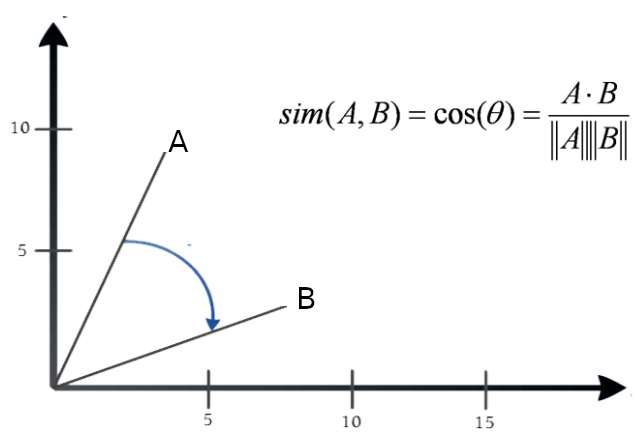

**Produto Escalar** <br>
Considere dois vetores A e B: <br>
$A = (a_1, a_2, \dots, a_n)$ <br>
$B = (b_1, b_2, \dots, b_n)$ <br>
O Produto Escalar entre A e B é dado por: <br>
$ A . B = (a_1 \times b_1) + (a_2 \times b_2) + \dots + (a_n \times b_n)$ <br>

**Norma de um vetor** <br>
Para um vetor V: <br>
$V = (v_1, v_2, \dots, v_n)$ <br>
A Norma de V é dada por: <br>
||V|| = $\sqrt{(v_1)^2 + (v_2)^2 + \dots + (v_n)^2}$

**Similaridade do Cosseno** <br>
A Similaridade do Cosseno entre dois vetores A e B é dada por: <br>
$sim(A,B) = \cos(\theta) = \frac{A . B} {||A|| \times ||B||}$

**Propriedades** <br>
- Valor entre -1 e 1 (geral) <br>
- Valor entre 0 e 1 (em várias aplicações de processamento de linguagem natural) <br>
- $\leq$ 0 (nenhuma similaridade) e 1 (similaridade total)

In [4]:
# computa a similaridade do Cosseno entre os embeddings
cosine_sim = cosine_similarity(embeddings_tfidf, embeddings_tfidf)
print(cosine_sim)

[[1.         0.71317547 0.         0.         0.         0.
  0.         0.        ]
 [0.71317547 1.         0.         0.17547958 0.         0.
  0.         0.        ]
 [0.         0.         1.         0.         0.         0.
  0.         0.        ]
 [0.         0.17547958 0.         1.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         1.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         1.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  1.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         1.        ]]


In [5]:
# computa os pares de similaridades
pairs = []
for i in range(len(cosine_sim)-1):
    for j in range(i+1, len(cosine_sim)):
        pairs.append({'index': [i, j], 'score': cosine_sim[i][j]})
# ordena as pontuações em ordem decrescente 
pairs = sorted(pairs, key=lambda x: x['score'], reverse=True)
for pair in pairs[0:26]:
    i, j = pair['index']
    print("{} \t\t {} \t\t Score: {:.4f}".format(sentences[i], sentences[j], pair['score']))

O rato roeu a roupa do rei 		 O rato roeu a roupa da rainha 		 Score: 0.7132
O rato roeu a roupa da rainha 		 O reinado da Rainha Elizabeth II foi o mais longo da história 		 Score: 0.1755
O rato roeu a roupa do rei 		 Ratos são animais roedores mamíferos 		 Score: 0.0000
O rato roeu a roupa do rei 		 O reinado da Rainha Elizabeth II foi o mais longo da história 		 Score: 0.0000
O rato roeu a roupa do rei 		 As eleições no Brasil estão muito polarizadas 		 Score: 0.0000
O rato roeu a roupa do rei 		 A economia mundial passa por um momento difícil 		 Score: 0.0000
O rato roeu a roupa do rei 		 Redes neurais são usadas para processamento de linguagem natural 		 Score: 0.0000
O rato roeu a roupa do rei 		 Transformers são usados para PLN 		 Score: 0.0000
O rato roeu a roupa da rainha 		 Ratos são animais roedores mamíferos 		 Score: 0.0000
O rato roeu a roupa da rainha 		 As eleições no Brasil estão muito polarizadas 		 Score: 0.0000
O rato roeu a roupa da rainha 		 A economia mundial pas

### Busca Léxica

Dada uma consulta, encontre o documento mais similar a ela, ou gere um ranking (ordenação) dos documentos em ordem decrescente de similaridade com a consulta.

In [6]:
# exemplo de consulta
query = 'Quem roeu a roupa do rei?'

# codifica a consulta
query_embedding_tfidf = tfidf_vectorizer.transform([query])
# imprime o número de elementos (comprimento, dimensão) do embedding gerado
print("Dimensão do embedding: ", query_embedding_tfidf.shape[1], "\n")
# imprime o embedding da consulta
print("Embedding da consulta: ", query_embedding_tfidf.todense()[0], "\n")

# computa a Similaridade do Cosseno entre a consulta e cada documento/sentença
cosine_sim = cosine_similarity(query_embedding_tfidf, embeddings_tfidf).reshape((-1,))
print("Similaridade entre a consulta e cada sentença:", cosine_sim, "\n")

# ordena as pontuações em ordem decrescente 
pairs = []
for i in range(len(cosine_sim)-1):
    pairs.append({'index': i, 'score': cosine_sim[i]})
pairs = sorted(pairs, key=lambda x: x['score'], reverse=True)
print("Ranking de similaridade das sentenças com a consulta:", query, "\n")
for pair in pairs:
    i = pair['index']
    print("{} \t\t Score: {:.4f}".format(sentences[i], pair['score']))

Dimensão do embedding:  31 

Embedding da consulta:  [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.64485945
  0.         0.         0.54044255 0.54044255 0.         0.
  0.        ]] 

Similaridade entre a consulta e cada sentença: [0.87974257 0.54044255 0.         0.         0.         0.
 0.         0.        ] 

Ranking de similaridade das sentenças com a consulta: Quem roeu a roupa do rei? 

O rato roeu a roupa do rei 		 Score: 0.8797
O rato roeu a roupa da rainha 		 Score: 0.5404
Ratos são animais roedores mamíferos 		 Score: 0.0000
O reinado da Rainha Elizabeth II foi o mais longo da história 		 Score: 0.0000
As eleições no Brasil estão muito polarizadas 		 Score: 0.0000
A economia mundial passa por um momento difícil 		 Score: 0.0000
Redes neurais são usadas para processamento de linguagem

-----------

## Classificação de Textos usando o Esquema de Pesos TF-IDF

Referências:<br>
https://medium.com/@claude.feldges/text-classification-with-tf-idf-lstm-bert-a-quantitative-comparison-b8409b556cb3

### Pacotes

In [7]:
# Processamento de dados
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelBinarizer

# Processamento de texto
import re
import nltk

# Data e Hora
from datetime import datetime

### Dataset

Conjunto de dados da BBC News contendo textos de notícias classificados em 5 categorias: esporte, negócio, política, tecnologia e entretenimento.

In [8]:
# Dataset a ser classificado
df = pd.read_csv("./datasets/bbc-text.csv")
df = df[["category", "text"]]

# Exibe os primeiros dados
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


### Análise dos Dados

O dataset contém 2.225 notícias classificadas em 5 categorias

In [9]:
print('Número total de notícias: {}'.format(len(df)))
print(40*'-')
print('Partição por categoria:')
print(df["category"].value_counts())
print(40*'-')
nr_categories = len(df["category"].unique())
print("Número de categorias: {n}".format(n=nr_categories))

Número total de notícias: 2225
----------------------------------------
Partição por categoria:
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: category, dtype: int64
----------------------------------------
Número de categorias: 5


In [10]:
# Exemplo da categoria n  (modifique o valor de n e verifique)
n=100
print('Categoria: ',df['category'][n])
print(100*'-')
print('Texto:')
print(df['text'][n])

Categoria:  entertainment
----------------------------------------------------------------------------------------------------
Texto:
housewives lift channel 4 ratings the debut of us television hit desperate housewives has helped lift channel 4 s january audience share by 12% compared to last year.  other successes such as celebrity big brother and the simpsons have enabled the broadcaster to surpass bbc two for the first month since last july. bbc two s share of the audience fell from 11.2% to 9.6% last month in comparison with january 2004. celebrity big brother attracted fewer viewers than its 2002 series.  comedy drama desperate housewives managed to pull in five million viewers at one point during its run to date  attracting a quarter of the television audience. the two main television channels  bbc1 and itv1  have both seen their monthly audience share decline in a year on year comparison for january  while five s proportion remained the same at a slender 6.3%. digital multi-cha

### Preparação dos Dados

Alguns algoritmos baseados em redes neurais recorrentes ou transformers são alimentados com os textos originais.<br>
Entretanto, para algoritmos que usam o TF-IDF, é necessário preprocessar os dados.

A função abaixo efetua as seguintes operações: <br>
- converte o texto para letras minúsculas e remove caracteres especiais
- separa o texto em tokens (i.e. converte de strings para listas de palavras)
- remove stopwords (i.e. remove palavras comuns como artigos, preposições e conjunções)
- converte as palavras para seus radicais (stemming)
- converte as palavras para seus lemas (lemmatization)

In [11]:
# Referência: Text Classification with NLP: Tf-Idf vs Word2Vec vs BERT from Medium

# Use stopwords da lista do nltk
lst_stopwords = nltk.corpus.stopwords.words("english")

nltk.download('wordnet')

def utils_preprocess_text(text, flg_stemm=False, flg_lemm=True, lst_stopwords=None):
    # Clean (convert to lowercase and remove punctuations and characters and then strip)
    # The function is not optimized for speed but split into various steps for pedagogical purpose
    text = str(text).lower()
    text = text.strip()
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize (convert from string to list)
    lst_text = text.split()
    # remove Stopwords
    if lst_stopwords is not None:
        lst_text = [word for word in lst_text if word not in lst_stopwords]

    # Stemming (remove -ing, -ly, ...)
    if flg_stemm == True:
        ps = nltk.stem.porter.PorterStemmer()
        lst_text = [ps.stem(word) for word in lst_text]

    # Lemmatisation (convert the word into root word)
    if flg_lemm == True:
        lem = nltk.stem.wordnet.WordNetLemmatizer()
        lst_text = [lem.lemmatize(word) for word in lst_text]

    # back to string from list
    text = " ".join(lst_text)
    return text

# Let's apply this function to the whole corpus
df["text_clean"] = df["text"].apply(lambda x: utils_preprocess_text(x, flg_stemm=False, flg_lemm=True, lst_stopwords=lst_stopwords))

# Let's look at the output
df.head()

[nltk_data] Downloading package wordnet to /home/denilson/nltk_data...


,category,text,text_clean
0,tech,tv future in the hands of viewers with home th...,tv future hand viewer home theatre system plas...
1,business,worldcom boss left books alone former worldc...,worldcom bos left book alone former worldcom b...
2,sport,tigers wary of farrell gamble leicester say ...,tiger wary farrell gamble leicester say rushed...
3,sport,yeading face newcastle in fa cup premiership s...,yeading face newcastle fa cup premiership side...
4,entertainment,ocean s twelve raids box office ocean s twelve...,ocean twelve raid box office ocean twelve crim...


### Partição em Treino e Teste

Particiona o dataset em 70% das instâncias para treino e 30% para teste, de forma estratificada, ou seja, mantendo a mesma proporção de dados em cada categoria.

In [12]:
# Renaming, Input -> X, Output -> y
X = df['text_clean']
y = df['category']
# Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=df['category'])

In [13]:
# Verifica o percentual de dados de treino
y_train.value_counts()/y.value_counts()

sport            0.698630
business         0.700000
politics         0.700240
tech             0.700748
entertainment    0.699482
Name: category, dtype: float64

### Treinamento do Classificador

- Gera os embeddings para cada instância de dado usando o esquema TF-IDF, por meio da classe TfidVectorizer.
- Usa o classificador Logistic Regression (Regressão Logística).
- Treina o classificador no conjunto de dados de treino, gerando o modelo de predição.

O modelo Logistic Regression é um modelo linear em que o algoritmo de minimização consiste em minimizar um função quadrática em seus parâmetros. O interessante é que essa função não tem mínimos locais, apenas um mínimo global, o qual pode ser alcançado. E pode seer alcançado usando um algoritmo simples e rápido, por meio da inversão de uma matriz do tamanho do vocabulário. A desvantagem é que uma vez que o mínimo é alcançado, é difícil melhorar o modelo (exceto adicionando-se a regularização). Assim, uma vez que o modelo é otimizado, há pouco espaço para melhoramentos.

In [14]:
# Gera os vetores de features TF-IDF (embeddings)
# max_features - constrói um vocabulário que considera somente as max_features (15.000, no caso abaixo)
# ordenadas pela frequência do termo na coleção
# ngram_range - extrai n-gramas de tamanho 1 e 2, ou seja, palavras únicas e sequências de duas palavras
vectorizer_tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1,2))

# Classificador da Regressão Logística
classifier_tfidf = LogisticRegression()

# Pipeline do modelo contendo o vetorizador e o classificador
model_tfidf = Pipeline([("vectorizer", vectorizer_tfidf), ("classifier", classifier_tfidf)])

# Treina o classificador gerando o modelo de predição
start_time = datetime.now()
model_tfidf.fit(X_train, y_train)
end_time = datetime.now()

training_time_tfidf = (end_time - start_time).total_seconds()

### Avaliação do Modelo

Avalia o modelo pela métrica 'acurácia", a qual retorna o percentual de acertos do classificador. Para isso, é feita a comparação das predições do modelo com os rótulos do dataset.

A avaliação é feita para ambos os dados de treino e teste. Isso é importante para verificar se não houve *overfitting*, que é um fenômeno que ocorre quando o modelo está fortemente ajustado aos dados de treino. Se a acurácia do treino for muito melhor do que a acurácia do teste, então isso pode indicar a ocorrência de *overfitting*.

Os resultados abaixo indicam que não houve *overfitting*. Caso haja *overfitting*, o modelo pode ser melhorado ajustando-se a regularização (*regularization*), a qual já vem por padrão no modelo de regressão logística. Um mecanismo típico de regularização é a regularização L2.

In [15]:
# Predição e avaliação nos dados de treino
predicted_train_tfidf = model_tfidf.predict(X_train)
accuracy_train_tfidf = accuracy_score(y_train, predicted_train_tfidf)
print('Acurácia nos dados de treino: {:.1%}'.format(accuracy_train_tfidf))

# Predição e avaliação nos dados de teste
predicted_test_tfidf = model_tfidf.predict(X_test)
accuracy_test_tfidf = accuracy_score(y_test, predicted_test_tfidf)
print('Acurácia nos dados de teste:  {:.1%}'.format(accuracy_test_tfidf))

print('Tempo de treinamento: {:.1f}s'.format(training_time_tfidf))

Acurácia nos dados de treino: 99.7%
Acurácia nos dados de teste:  97.9%
Tempo de treinamento: 2.4s


### Análise Final

Obtém as palavras mais relevantes para a classificação em cada categoria. A relevância é ordenada pelo peso TF-IDF da cada palavra.

In [16]:
print('Classes do modelo: ',classifier_tfidf.classes_)
print(80*'-')
print('Formato dos coeficientes do modelo (categorias x tamanho do vocabulario): ', classifier_tfidf.coef_.shape)
print(80*'-')
NN = 10
# Get the 10 (here: NN, which you can adjust yourself) ids of the words with highest weights per category
top_words = np.argsort(classifier_tfidf.coef_,axis=1)[:,-NN:]

# Get the vocabulary of the model (mapping of words to ids):
voc = vectorizer_tfidf.vocabulary_
# Get the inverse vocabulary to map the ids of the words to the words:
inv_voc = {v: k for k, v in voc.items()}

# Get for each category (=class) the top ten words
for n, w in enumerate(classifier_tfidf.classes_):
    t = w + ': '
    for i in range(NN):
        t += inv_voc[top_words[n,i]]
        if i!=NN:
            t+=', '
    print(t)
    print(80*'-')

Classes do modelo:  ['business' 'entertainment' 'politics' 'sport' 'tech']
--------------------------------------------------------------------------------
Formato dos coeficientes do modelo (categorias x tamanho do vocabulario):  (5, 15000)
--------------------------------------------------------------------------------
business: economy, economic, price, growth, profit, market, bank, firm, share, company, 
--------------------------------------------------------------------------------
entertainment: chart, tv, singer, album, band, star, award, music, show, film, 
--------------------------------------------------------------------------------
politics: mp, blair, tory, lord, minister, election, government, labour, mr, party, 
--------------------------------------------------------------------------------
sport: team, season, england, coach, win, champion, cup, player, club, match, 
--------------------------------------------------------------------------------
tech: online, site, 

# Fim

Esses foram os passos para a representação de documentos usando o esquema de pesos TF-IDF. Você aprendeu a usar o esquema TF-IDF para as tarefas de busca léxica e para classificação de textos.

-------------------------------------------